# Two Dimensional Deconvolution of Chromatin Occupancy Trial

Here, we will attempt to deconvolve the chromatin around a gene. We have shown that we can deconvolve a matrix f and g with the convex optimization in a toy example in the "Proof of Concept, Matrix f and g" notebook. 

Now we will try a more complex example. In which we load the chromatin occupancy data for a gene and attempt to perform deconvolution on the gene's occupancy (2 or more values by time) in a convex optimization run.

Steps:
1. Load the chromatin occupancy data (we can start with nucleosome gene body occupancy + small fragments promoter occupancy).
2. Load the proper model (RG1 model for Yulong's dataset).
3. Construct g properly as a matrix. Will need to update the model code.
4. Update the deconvolution code to handle the additional dimension (wavelet and optimization code may not need much change, but we'll need to double check and make sure the shapes and sizes of all of the data structures are what they should be.
5. Perform the deconvolution
6. Evaluate the results.

In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
from cc_src.sgd import get_gene_name_orf_name
orf_name, gene_name = get_gene_name_orf_name('CLB2')

In [95]:
# Load the chromatin data
prom_sm_occ = pd.read_csv('datasets/yl_rep2_occupancy_for_deconv_2023_10_06/'\
                          'chrom_yl_rep2_prom_sm_occ.tsv', header=None,
                          sep='\t')
orf_names = pd.read_csv('datasets/yl_rep2_occupancy_for_deconv_2023_10_06/orf_names.csv', 
                        header=None)[0].values
prom_sm_occ.index = orf_names

nuc_gb_occ = pd.read_csv('datasets/yl_rep2_occupancy_for_deconv_2023_10_06/'\
                         'chrom_yl_rep2_gb_nuc_occ.tsv', header=None,
                          sep='\t')
nuc_gb_occ.index = orf_names

# Load for the gene
prom_g = prom_sm_occ.loc[orf_name].values
nuc_g = nuc_gb_occ.loc[orf_name].values

# Stack the promoter small fragments and gene body nucleosomes
# into a matrix of dimension: (time x 2)
chromatin_g = np.stack([prom_g, nuc_g], axis=1)

# Drop the 110 timepoint (4th from the end). 
# TODO: I'm not sure if we still need to do this
# But the gene expression data has it dropped. We can come back to this later...
chromatin_g = np.concatenate([chromatin_g[:-4], chromatin_g[-3:]])

print("The shape of the chromatin matrix, G is: ", chromatin_g.shape)


The shape of the chromatin matrix, G is:  (14, 2)


In [97]:
from src.config import load_yl_replicate2_gene_expression_config, \
    load_xg_gene_expression_config
from src.model import Model

# We will load the configuration and model for the gene.
# Note this is still for the gene expression configuration.
# We are most interested in the H matrix.
config = load_yl_replicate2_gene_expression_config()
model = Model(config, gene_name, 0.004)
print("The shape of the convolution kernel matrix, H is: ", model.H.shape)

The shape of the convolution kernel matrix, H is:  (14, 258)


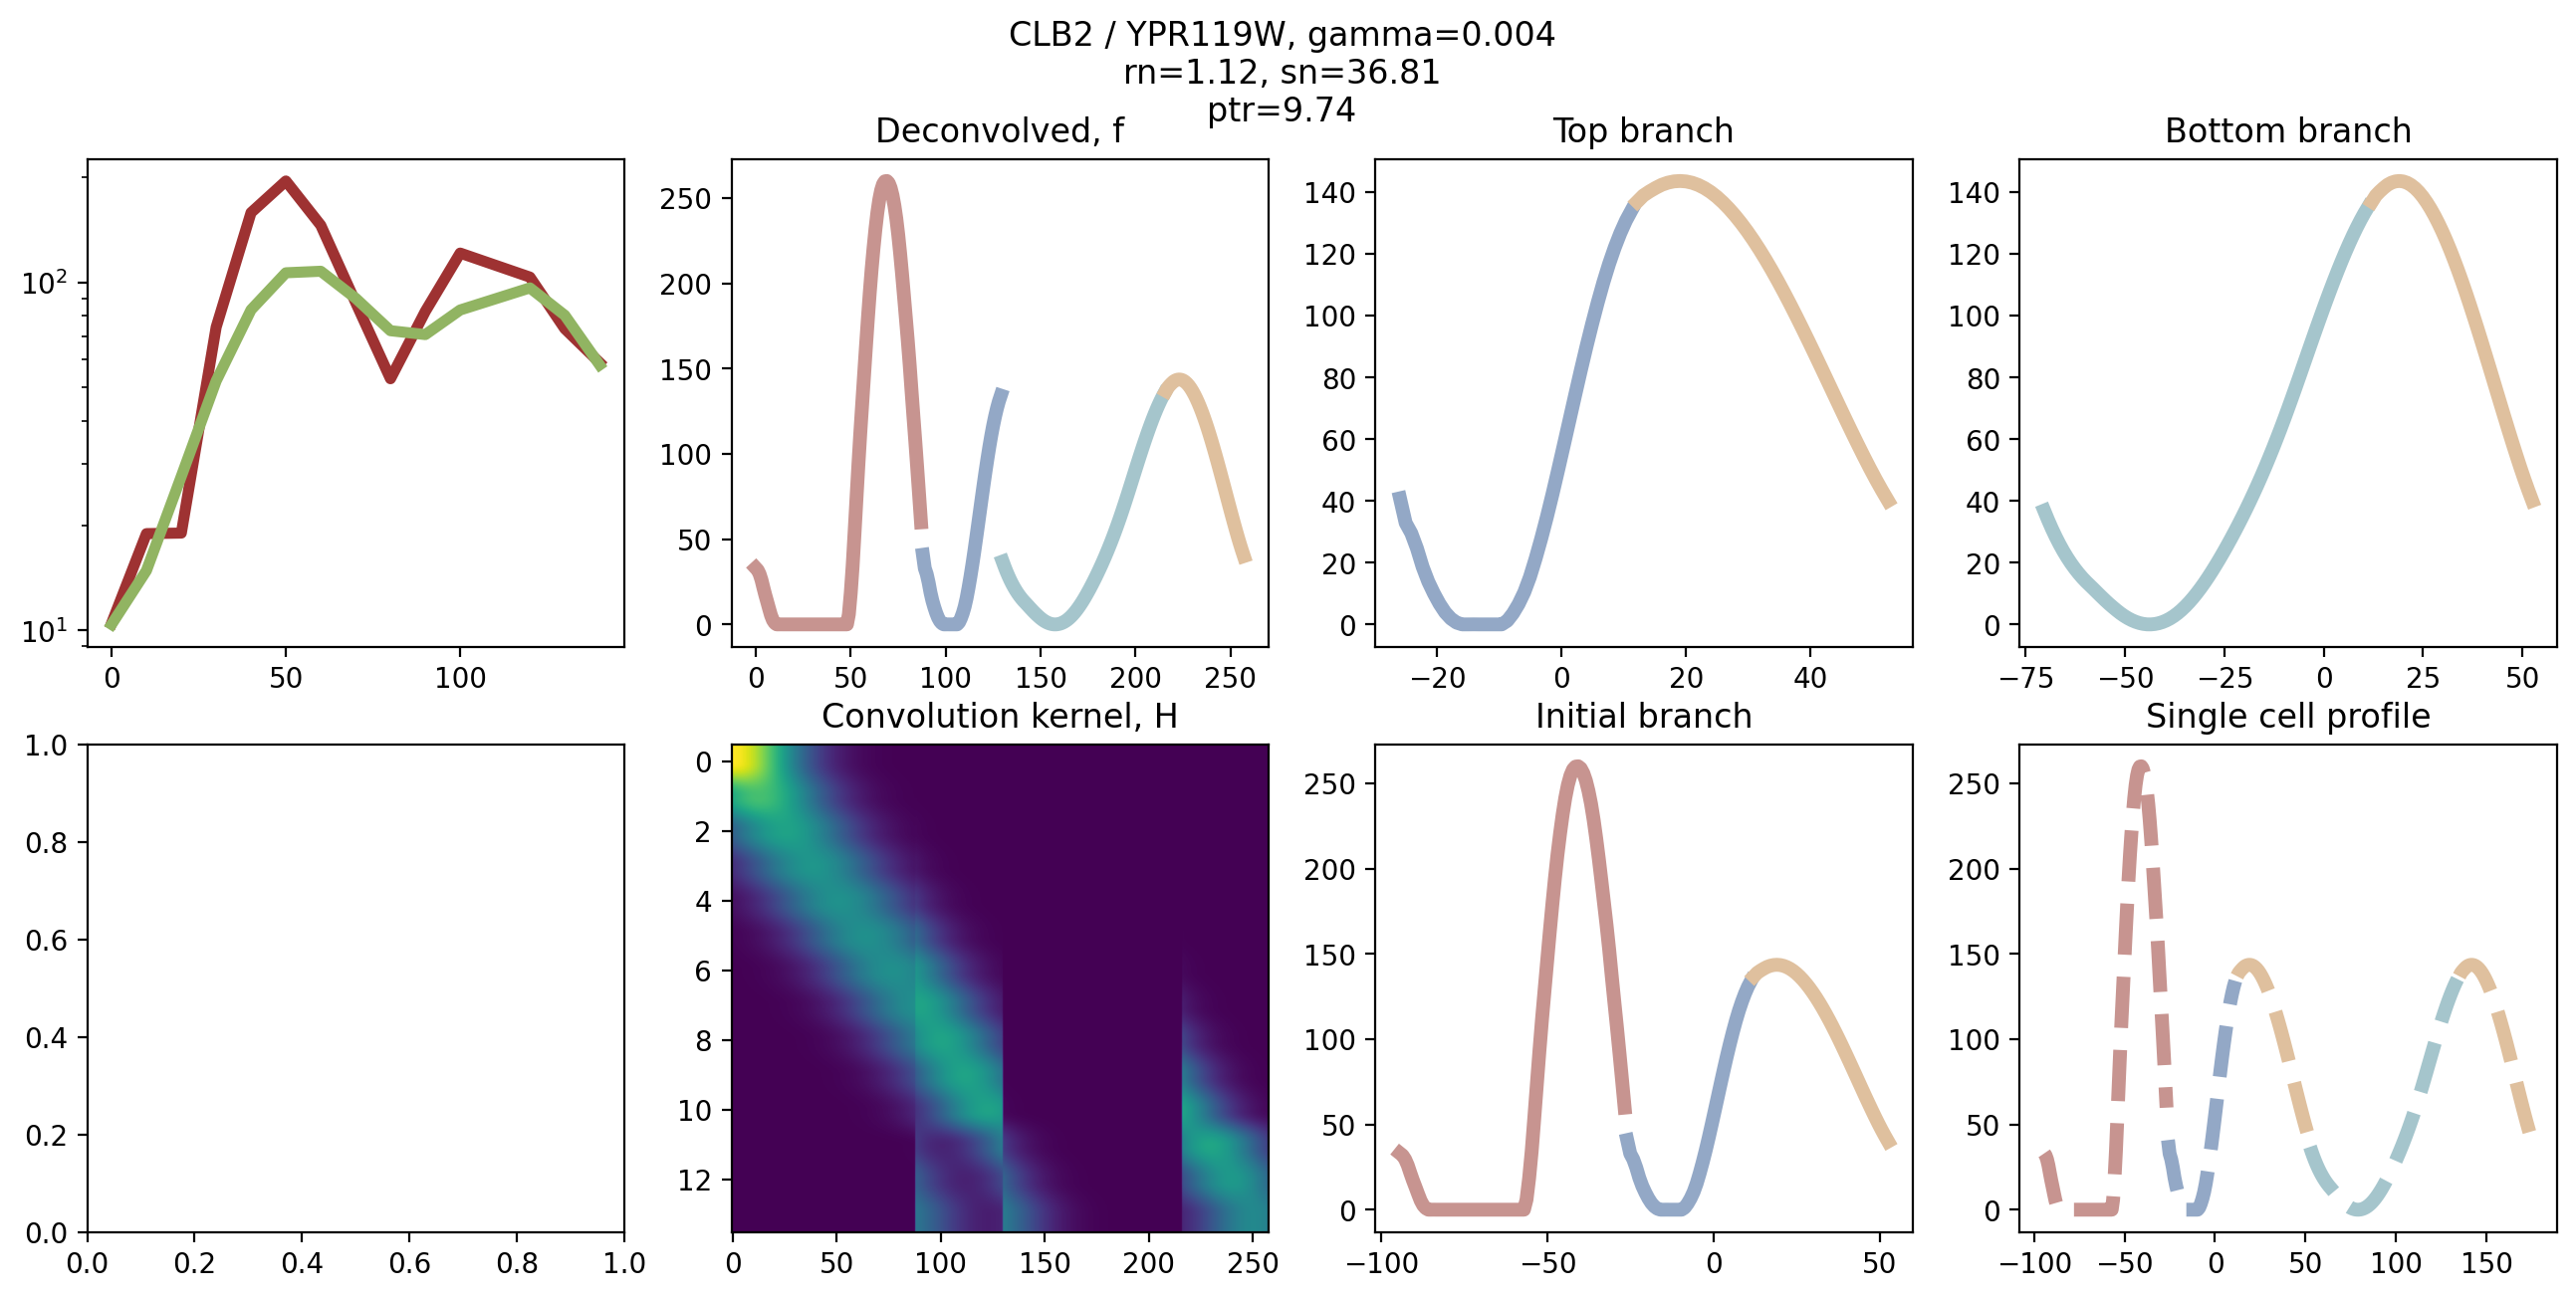

In [86]:
# Testing gene expression deconvolution for reference.
model.deconvolve()
model.plot_deconvolved_gene()

Text(0.5, 1.0, 'The fit 2, H*f')

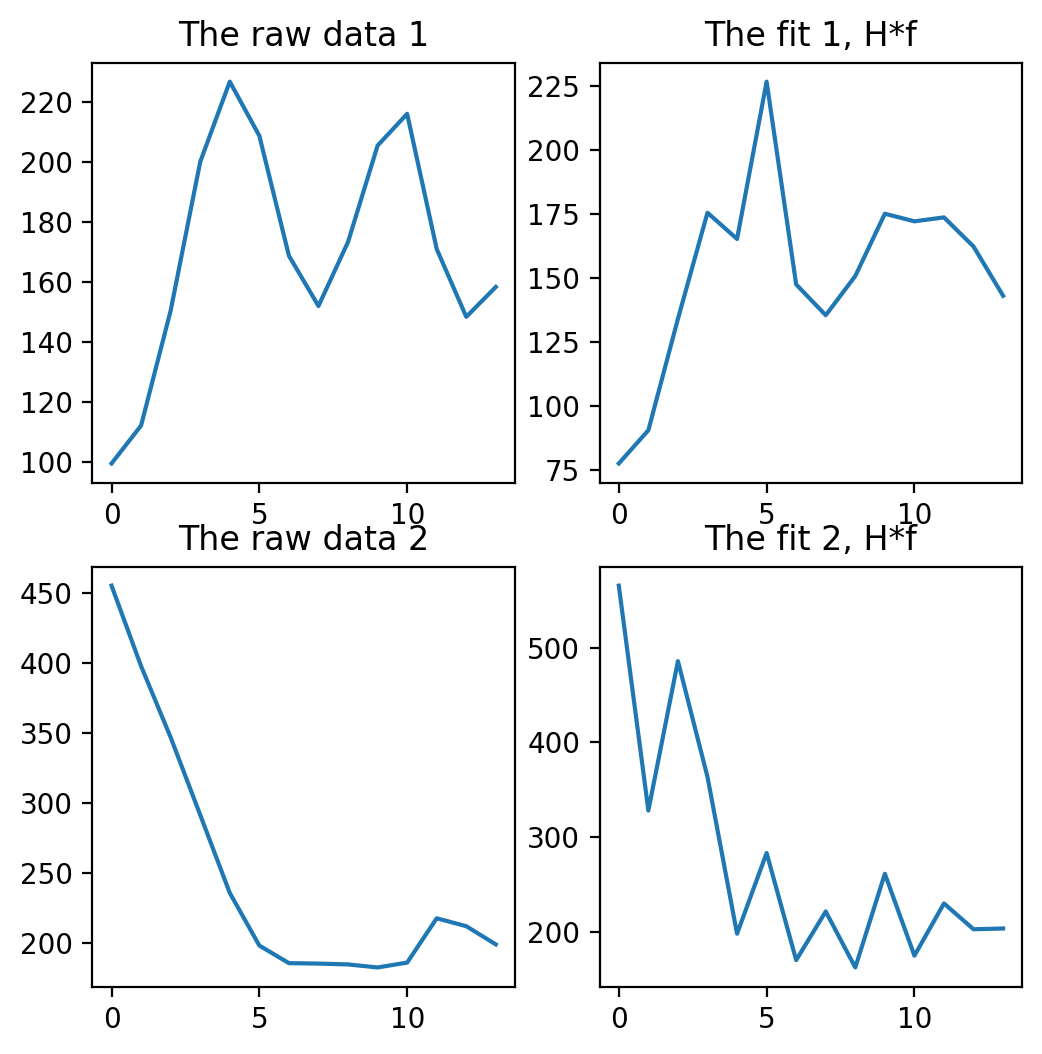

In [102]:
import cvxpy as cp

H = model.H
g = chromatin_g

# And we are trying to determine the best f (4x1) that
# minimizes Hxf / g - 1, (4x4) * (4x2) / (4x2) - 1
f = cp.Variable((H.shape[1], g.shape[1]))

# # We will imgine that the subset of the "initial" and 
# # "top" branches will be the first two indices of the f vector
# f_it = [0, 1]

# # # And the bottom branch will be the last two indices
# f_b = [2, 3]

# # Then we will make wavelets of the appropriate size
# W1 = get_wavelet_kernel(WAVETYPE, len(f_it), WAVEPAR)
# W2 = get_wavelet_kernel(WAVETYPE, len(f_b), WAVEPAR)

# Add the wavelet smoothing constraint to the convex optimization
objective = cp.Minimize(cp.square(cp.pos(cp.norm(H@f/g - 1))))
#                         +
#                         gamma * (cp.norm(W1@f[f_it], 1) +
#                                  cp.norm(W2@f[f_b], 1))
#                        )

# Where f is non-negative
constraints = [f >= 0]

# Perform the convex optimization
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.CLARABEL)

# # -----------------------

# Plot the result
predicted_G = np.matmul(H, f.value)

# Thus, this simple example is resolved.
plt.figure(figsize=(6, 6))
plt.subplot(2, 2, 1)
plt.plot(predicted_G[:, 0])
plt.title("The raw data 1")
plt.subplot(2, 2, 2)
plt.plot(g[:, 0])
plt.title("The fit 1, H*f")

plt.subplot(2, 2, 3)
plt.plot(predicted_G[:, 1])
plt.title("The raw data 2")

plt.subplot(2, 2, 4)
plt.plot(g[:, 1])
plt.title("The fit 2, H*f")
